<a href="https://colab.research.google.com/github/zlwym/IAT461_Final_Project/blob/main/final_project_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview

In [ ]:
#Load the dataset
df = pd.read_csv("listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,52113003,https://www.airbnb.com/rooms/52113003,20260615212204,2026-06-16,city scrape,King Bed Loft in the Heart of Downtown Boston,"Welcome to our spacious, open-concept loft in ...",NaN,https://a0.muscache.com/pictures/b9802ab5-b0ef...,20828559,...,4.99,4.89,4.84,STR-516048,NaN,1,1,0,0,4.77
1,695542274861997846,https://www.airbnb.com/rooms/695542274861997846,20260615212204,2026-06-16,city scrape,Super 2 Bedroom apt in Beacon Hill Boston,Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,373675137,...,5.00,5.00,5.00,NaN,NaN,117,53,64,0,0.11
2,9110708,https://www.airbnb.com/rooms/9110708,20260615212204,2026-07-06,previous scrape,Cozy & sunny apartment BU/Allston,"Cozy 1BR, 1BA apartment in central area of All...",NaN,https://a0.muscache.com/pictures/8b1a6c2f-3135...,32018716,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
3,197972,https://www.airbnb.com/rooms/197972,20260615212204,2026-06-16,city scrape,Serene Studio in a Perfect Location,"Our 500 sf 2 room apartment is quiet, private ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,965697,...,4.97,4.92,4.81,STR-409453,NaN,2,2,0,0,3.33
4,706445990952752456,https://www.airbnb.com/rooms/706445990952752456,20260615212204,2026-06-16,city scrape,Spacious 1br In Boston FIDI | Close to T!,This wonderful 1 bedroom apartment is located ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,382451810,...,4.91,4.91,4.63,STR-489695,NaN,43,43,0,0,4.21


I can see right off the bat that there is some "useless" data that I can drop, such as identifiers and host data. There are also some entirely null columns to drop.

In [ ]:
df.shape

(4378, 90)

There are 4378 rows and 90 columns. I will definitely not be using all 90 columns as features and will narrow these down.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4378 entries, 0 to 4377
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4378 non-null   int64  
 1   listing_url                                   4378 non-null   object 
 2   scrape_id                                     4378 non-null   int64  
 3   last_scraped                                  4378 non-null   object 
 4   source                                        4378 non-null   object 
 5   name                                          4378 non-null   object 
 6   description                                   4319 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   4378 non-null   object 
 9   host_id                                       4378 non-null   i

In [ ]:
df.describe()

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4.378000e+03,4.378000e+03,0.0,4.378000e+03,4.360000e+03,0.0,4360.000000,4360.000000,4360.000000,4360.000000,...,3476.000000,3477.000000,3476.000000,3476.000000,0.0,4378.000000,4378.000000,4378.000000,4378.000000,3477.000000
mean,8.176489e+17,2.026062e+13,NaN,1.266426e+16,1.473194e+18,NaN,7.994725,5.775229,6.606881,5.677064,...,4.856392,4.848225,4.765570,4.625046,NaN,30.073550,24.379625,4.978986,0.009822,1.727291
std,6.442407e+17,2.375271e+00,NaN,1.453351e+17,3.387821e+16,NaN,4.064542,3.547266,4.179232,3.409409,...,0.317106,0.329988,0.327309,0.419755,NaN,52.975297,51.752829,12.400281,0.098629,1.882912
min,3.781000e+03,2.026062e+13,NaN,4.804000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,4.553112e+07,2.026062e+13,NaN,2.234822e+07,1.462889e+18,NaN,5.000000,3.000000,3.000000,3.000000,...,4.840000,4.840000,4.680000,4.520000,NaN,2.000000,1.000000,0.000000,0.000000,0.280000
50%,9.659016e+17,2.026062e+13,NaN,1.074344e+08,1.465718e+18,NaN,9.000000,6.000000,7.000000,6.000000,...,4.940000,4.940000,4.870000,4.720000,NaN,7.000000,3.000000,0.000000,0.000000,1.070000
75%,1.415532e+18,2.026062e+13,NaN,3.824518e+08,1.469716e+18,NaN,11.000000,9.000000,10.000000,9.000000,...,5.000000,5.000000,4.990000,4.860000,NaN,34.000000,19.000000,3.000000,0.000000,2.650000
max,1.706947e+18,2.026062e+13,NaN,1.694941e+18,1.706947e+18,NaN,17.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,227.000000,227.000000,64.000000,1.000000,24.160000


In [ ]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

Checking for any duplicates in the dataset.

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df['id'].duplicated().sum())

0


There are no duplicates.

# Column Selection

Not all of the columns here will be useful for predicting price per night. There are 90 columns. Not all are useful and some are duplicates. I'm going to be choosing which to keep and which to get rid of.

I will also be dropping host information. My reason for doing so is because professional rental companies do not have individual hosts the same way Airbnb does. When going through a company, you are not dealing with private homeowners. Any of the host data wouldn't be available for a professional rental company and therefore can't be used to evaluate properties where host data doesn't exist.

In [ ]:
columns = [
    "price",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "number_of_reviews_ly",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "availability_eoy",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "amenities"
]

#Use just these columns

df = df[columns]

In [ ]:
df.shape

(4378, 29)

From 90 columns down to 29. I may remove some of these later after further analysis.

I chose these initial columns based on location, size, room type, review quality, and popularity as these are features that have impact on the price of a rental.

# Price Cleaning

In the price column, prices with more than 3 digits are expressed using a comma. Prices also have "$" before them. This is arguably the most important column, so I'll be cleaning it by removing the commas.

In [ ]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [ ]:
print(df['price'].dtype)

float64


Prices are now floats instead of objects.

# Missing Values

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    df.isnull()
      .mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})

missing_df

,Missing Values,Percent
bedrooms,1261,28.803106
bathrooms,1030,23.526725
beds,929,21.219735
review_scores_value,902,20.603015
review_scores_location,902,20.603015
review_scores_accuracy,902,20.603015
review_scores_checkin,902,20.603015
review_scores_communication,901,20.580174
reviews_per_month,901,20.580174
review_scores_cleanliness,901,20.580174


There are a lot of missing values to handle, and I can't get rid of all of them since this isn't a huge dataset. I will definitely be dropping all the null values in the price column, as this is what I'm trying to predict. Therefore, it makes no sense for me to do any kind of imputation.

In [ ]:
df = df.dropna(subset = ["price"])

In [ ]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    df.isnull()
      .mean()*100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})

missing_df

,Missing Values,Percent
bedrooms,1062,28.757108
review_scores_communication,616,16.680206
review_scores_location,616,16.680206
review_scores_value,616,16.680206
reviews_per_month,616,16.680206
review_scores_rating,616,16.680206
review_scores_accuracy,616,16.680206
review_scores_cleanliness,616,16.680206
review_scores_checkin,616,16.680206
bathrooms,520,14.080693


For the rest of the values, I will do median imputation. I'm doing this because removing all these values is too big a loss to the dataset. Median imputation will make the values less swayed by outliers.

In [ ]:
df = df.fillna(
    df.median(numeric_only=True)
)

# Distribution of Prices

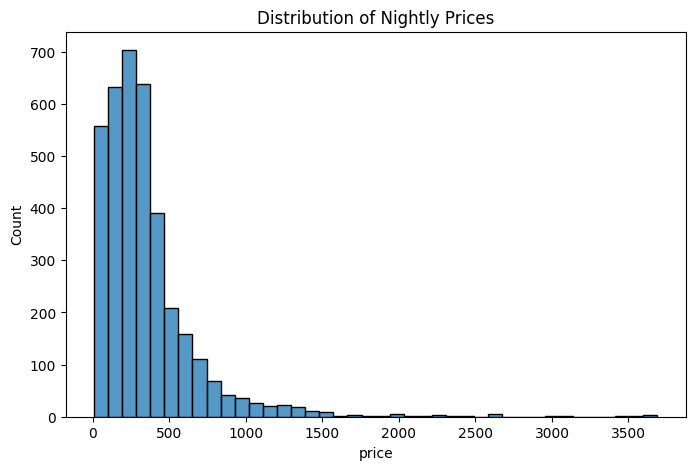

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=40)

plt.title("Distribution of Nightly Prices")

plt.show()

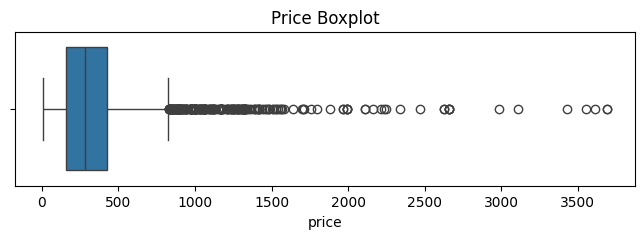

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=df["price"])

plt.title("Price Boxplot")

plt.show()

This data is heavily right skewed. During modeling, I'm going to test out the log transformed versus the raw data to see which performs better.

In [ ]:
df["price"].describe(percentiles=[0.90,0.95,0.99])

,price
count,3693.000000
mean,349.678708
std,330.250007
min,7.500000
50%,278.850000
90%,669.822000
95%,922.598000
99%,1558.133600
max,3689.380000


There are some outliers here including a minimum price of 7.50 and a maximum price of 3689.38. While these could definitely be possible, they are unlikely.

When I went to inspect the data, there isn't much of a difference between these ultra low and high values. The $3689 listing still has one bath, 1 bathroom, and 2 beds. However, after looking at the listing's coordinates on Google Maps, it's a private property and entire home rental right on the water in central Boston. So, this could be plausible.

Looking at the lowest prices, these rentals are mostly single rooms within residential houses. Looking up the coordinates, they are also far out of Boston's city centre.

I'm going to leave these values for now, since they are indeed possible, and return to them if needed during modeling.

# Correlation

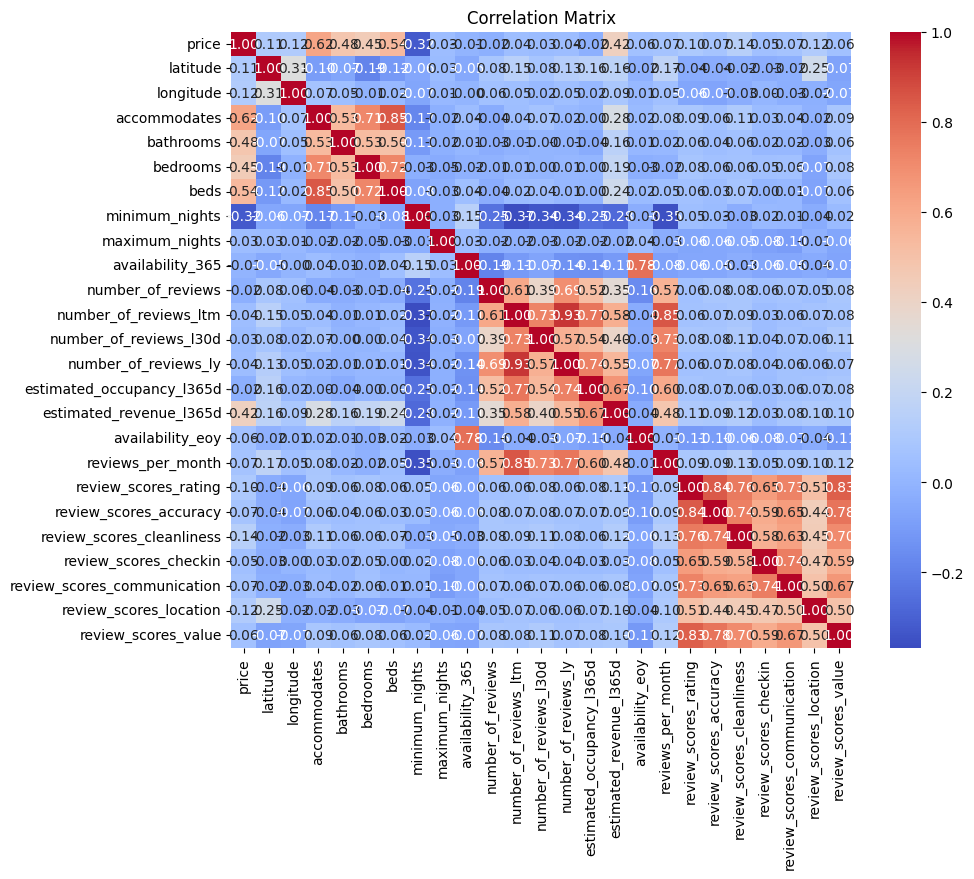

In [ ]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Looking at the correlation matrix, it seems like reviews per month and minimum nights are strongly correlated. Minimum nights seems to be correlated with a lot of features. It's interesting that some of the review categories correlate with minimum nights. As well, estimated revenue, estimated occupancy, and price are strongly correlated with minimum nights. This makes sense, because I'd presume that higher minimum nights means that people stay for longer. It likely correlates with larger occupancy properties that can accomodate more people for longer, therefore costing more.

# Some Visualizations

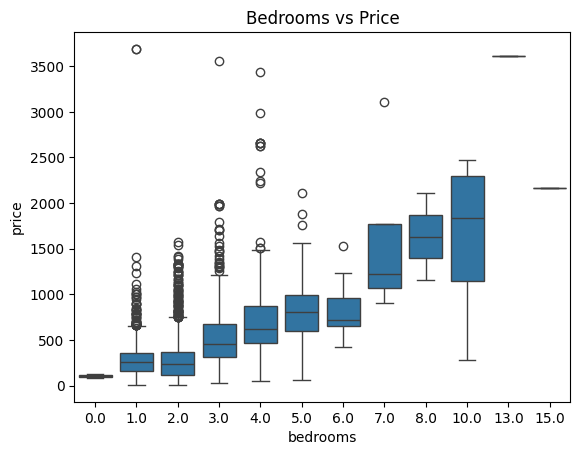

In [ ]:
sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("Bedrooms vs Price")

plt.show()

It makes sense that the more bedrooms there are, the higher the price on average.

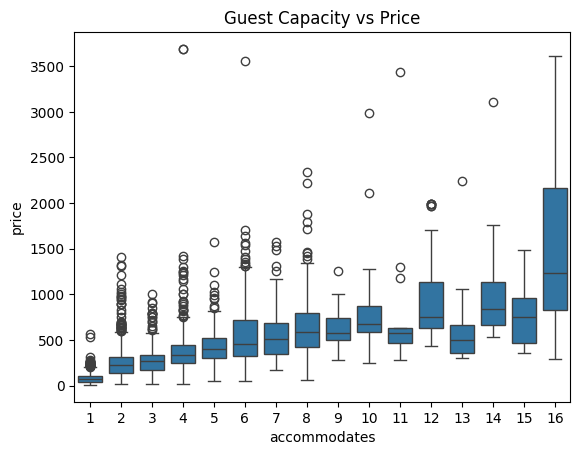

In [ ]:
sns.boxplot(
    data=df,
    x="accommodates",
    y="price"
)

plt.title("Guest Capacity vs Price")

plt.show()

Same for capacity. The higher the capacity, the higher the price is expected to be.

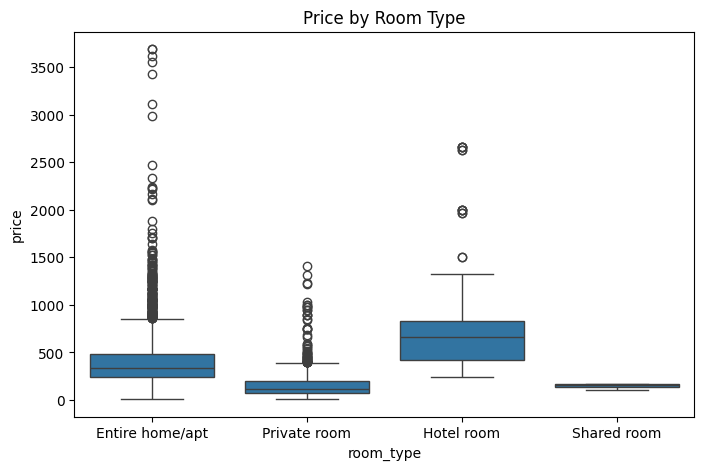

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Price by Room Type")

plt.show()

Here, I would expect the entire home/apt to have the higheset pricing. However, it looks like hotel rooms on average are more expensive, while homes/apartments have higher outliers.

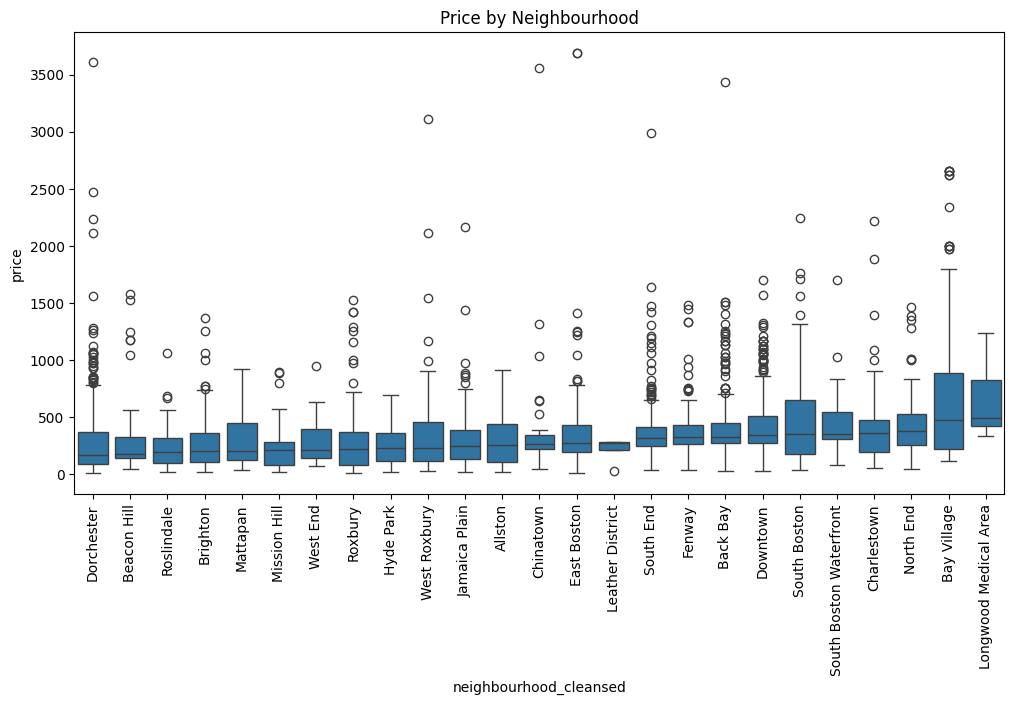

In [ ]:
plt.figure(figsize=(12,6))

order = (
    df.groupby("neighbourhood_cleansed")["price"]
      .median()
      .sort_values()
      .index
)

sns.boxplot(
    data=df,
    x="neighbourhood_cleansed",
    y="price",
    order=order
)

plt.xticks(rotation=90)

plt.title("Price by Neighbourhood")

plt.show()

Bay Village appears to be the most expensive area overall. Google also confirms that this is the most expensive neighbourhood in all of Boston.

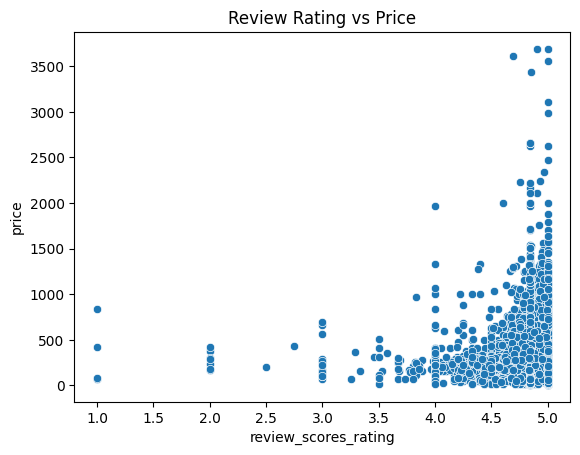

In [ ]:
sns.scatterplot(
    data=df,
    x="review_scores_rating",
    y="price"
)

plt.title("Review Rating vs Price")

plt.show()

I'm not sure if this graph just looks like this because there are more ratings for listings at lower prices or because of outliers.

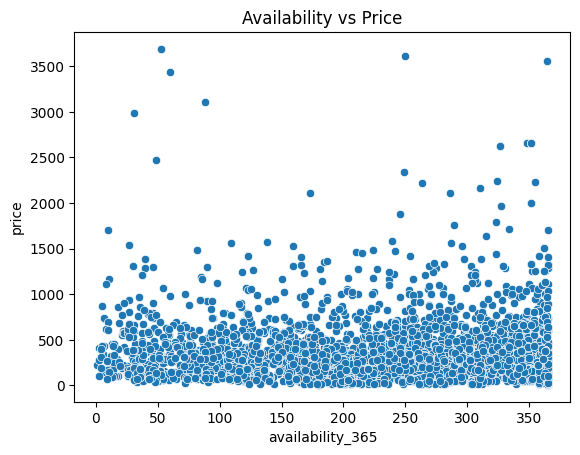

In [ ]:
sns.scatterplot(
    data=df,
    x="availability_365",
    y="price"
)

plt.title("Availability vs Price")

plt.show()

This one has no noteable patterns.

In [ ]:
df["amenity_count"] = df["amenities"].apply(
    lambda x: len(str(x).split(","))
)

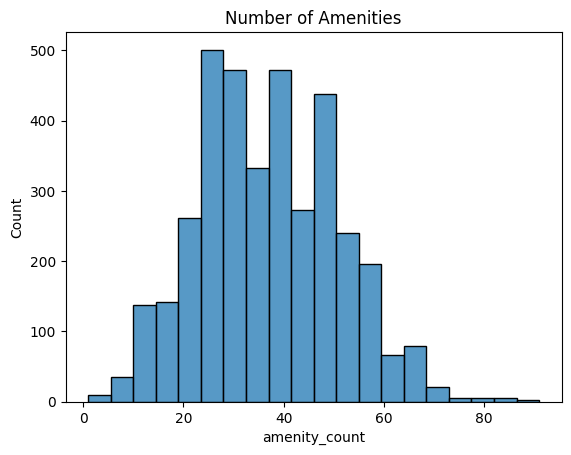

In [ ]:
sns.histplot(df["amenity_count"], bins=20)

plt.title("Number of Amenities")

plt.show()

This is the distribution of number of amenities.

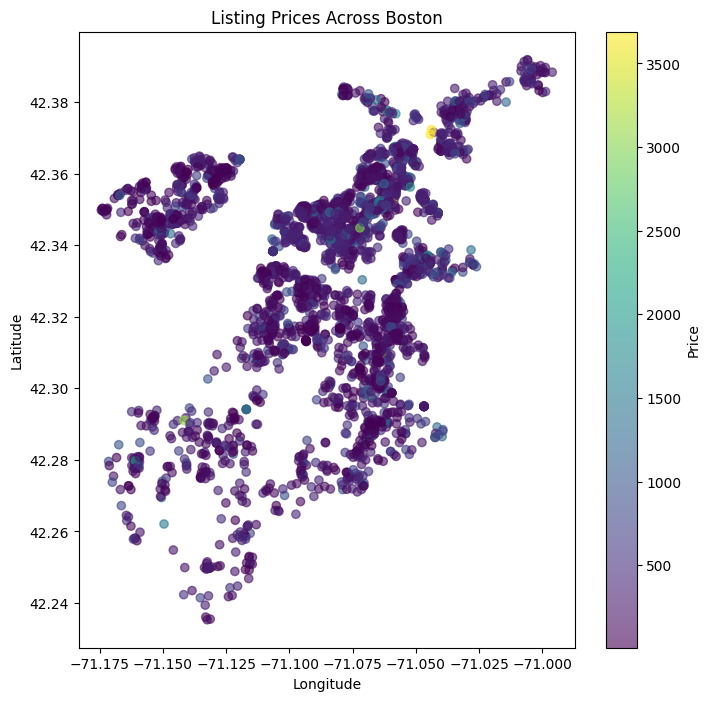

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Price")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title("Listing Prices Across Boston")

plt.show()

This shows areas that are densely populated with rentals and ones that are less so.

In [ ]:
corr_price = (
    numeric.corr()["price"]
    .sort_values(ascending=False)
)

corr_price

,price
price,1.000000
accommodates,0.620444
beds,0.540095
bathrooms,0.482033
bedrooms,0.448015
estimated_revenue_l365d,0.421468
review_scores_cleanliness,0.143848
longitude,0.118800
review_scores_location,0.117247
latitude,0.110646


# Re-evaluating Columns

I'll be getting rid of one more column, estimated revenue in the last 365 days. This is because this data depends on the price, which is what I'm trying to predict.

In [ ]:
df = df.drop(columns='estimated_revenue_l365d')

# Progress Report

For this project, I'm going to be doing supervised regression because there's one continuous numeric target outcome which is the nightly price. My objective is to have the model learn the relationship between a property's characteristics and its nightly price. These properties will be related to location, size, reviews, and availability.

So far, I have done this EDA. I first loaded the dataset into a dataframe and did an initial inspection. The dataset contained 90 columns, which is far too many to use as features. A lot of these were also irrelevant to the price, or contained host information that wouldn't be useful to an actual rental. I excluded any irrelevant information and kept only 29 columns in the end (and removed one more to make 28 later on).

I then cleaned data for the target variable of price by making the data consistent, removing $ and commas. I also checked outliers, which I deemed plausible because of their type and location. I plan on testing the model with the raw data as well as data without outliers.

I then handled missing values. For the price column, I dropped all null values. There is no point using imputation here since this is the column I'm trying to predict. For the rest of the values, I did median imputation as dropping these values would remove too much of the dataset. Median imputation as opposed to mean will reduce the chance of being impacted by outliers.

I then created visualizations to better understand the data. This will help me move on with the project as I plan on completing more data preprocessing, engineering features, and encoding categorical variables to prepare the data for machine learning. I will then split the data into training and test sets. Some models I'm thinking of using are Linear Regression, Decision Tree Regression, and Random Foreset Regression. I'll then evaluate the model.

If I have time for it, I would also like to build an interactive Streamlit app clustering listings based on features and pricing across a map.